# Plots for figure 3

## Tree
The Tree plot is generated using Itol and is not included in the notebook.
The files to recreate the tree is in Data/figure3

## Thermal Shift Assay (TSA) 
Data from round 3 and round 4 experiments is included

Data is only featured from Lineage 1,2,5 since these were the only active variants, (Lineage 3 WT were not active)

## Relative Activity after heating
Data from round 3

Data from Lineage 1,2,3,4,5

## Kinetics
Data from round 3 variants and MPNN control

Data from Lineage 2 (A0A372IUB3) variants


# Thermal Shift Assay (TSA)

In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from Bio import SeqIO
from glob import glob
from scipy.optimize import curve_fit

import sklearn
from scipy.stats import pearsonr, spearmanr

from Helpers.helper_figure2 import *

# Summary TM


In [2]:
File_TM_B3 = "../Data/Figure3/TSA_summary_round3.csv"
File_TM_B4 = "../Data/Figure3/TSA_summary_round4.csv"


In [3]:


df_TM_B3 = pd.read_csv(File_TM_B3)
df_TM_B4 = pd.read_csv(File_TM_B4)

df_TM_B3 = df_TM_B3[["#Annotation", "#Tm"]]
df_TM_B4 = df_TM_B4[["#Annotation", "#Tm"]]


/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Scripts/Helpers/helper_figure2.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


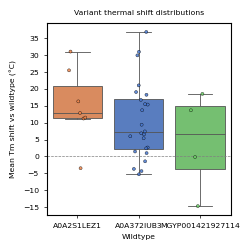

In [4]:
tm_summary_B3, variant_shift_B3 = summarize_tm_shifts(df_TM_B3)
tm_summary_B4, variant_shift_B4 = summarize_tm_shifts(df_TM_B4)


variant_shift_points_B3 = prepare_variant_shift_plot_df(df_TM_B3, "Batch 3")
variant_shift_points_B4 = prepare_variant_shift_plot_df(df_TM_B4, "Batch 4")
variant_shift_plot_df = pd.concat([variant_shift_points_B3, variant_shift_points_B4], ignore_index=True)

split_hues_by_batch = False
plot_size_mm = (60, 60)
plot_font_size = 5.5

plot_variant_shift_boxplot(
    variant_shift_plot_df,
    split_hues_by_batch=split_hues_by_batch,
    size_mm=plot_size_mm,
    font_size=plot_font_size
)
plt.savefig("../Results/Figure3/Box_plot_TM_diff.pdf", bbox_inches="tight")
plt.show()

Batch 3 wildtype / variant pairs loaded from Data/Figure3


,wildtype_id,variant_name,Tm_difference_vs_wildtype,variant_mean_Tm,wildtype_mean_Tm,variant_curve_replicates,wildtype_curve_replicates
0,A0A2S1LEZ1,A0A2S1LEZ1_362,31.028,71.444,40.416,3,3
1,A0A372IUB3,A0A372IUB3_1847,36.835,92.292,55.457,3,3
2,MGYP001421927114,MGYP001421927114_1344,18.507,67.334,48.827,3,3


,wildtype_id,sample_type,sample_name,replicate_id,Tm,R_square,curve_file
0,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,1,40.175,0.9991,A0A2S1LEZ1_rep1.txt
1,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,2,40.434,0.9985,A0A2S1LEZ1_rep2.txt
2,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,3,40.640,0.9976,A0A2S1LEZ1_rep3.txt
3,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,1,71.662,0.9795,A0A2S1LEZ1_362_rep1.txt
4,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,2,71.342,0.9849,A0A2S1LEZ1_362_rep2.txt
5,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,3,71.328,0.9836,A0A2S1LEZ1_362_rep3.txt
6,A0A372IUB3,Wildtype,A0A372IUB3,1,56.823,0.9963,A0A372IUB3_rep1.txt
7,A0A372IUB3,Wildtype,A0A372IUB3,2,55.912,0.9947,A0A372IUB3_rep2.txt
8,A0A372IUB3,Wildtype,A0A372IUB3,3,53.636,0.9984,A0A372IUB3_rep3.txt
9,A0A372IUB3,Best variant,A0A372IUB3_1847,1,92.405,0.9983,A0A372IUB3_1847_rep1.txt


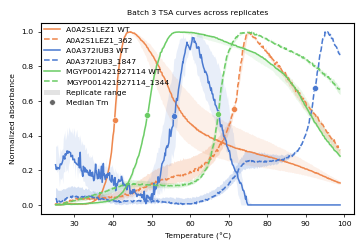

In [5]:
result_summary_B3_full = pd.read_csv(File_TM_B3)
curve_dir_B3 = os.path.dirname(File_TM_B3)

curve_pairs_B3, curve_replicates_B3, curve_data_B3 = prepare_tsa_curve_data_from_directory(
    curve_dir_B3,
    result_summary_B3_full
)

print("Batch 3 wildtype / variant pairs loaded from Data/Figure3")
display(
    curve_pairs_B3[[
        "wildtype_id",
        "variant_name",
        "Tm_difference_vs_wildtype",
        "variant_mean_Tm",
        "wildtype_mean_Tm",
        "variant_curve_replicates",
        "wildtype_curve_replicates"
    ]].round(3)
)

display(
    curve_replicates_B3[[
        "wildtype_id",
        "sample_type",
        "sample_name",
        "replicate_id",
        "Tm",
        "R_square",
        "curve_file"
    ]].round({"Tm": 3, "R_square": 4})
)

curve_plot_size_mm = (89, 60)
curve_plot_font_size = 5.5

plot_tsa_replicate_bands(
    curve_data_B3,
    curve_pairs_B3,
    size_mm=curve_plot_size_mm,
    font_size=curve_plot_font_size,
    title="Batch 3 TSA curves across replicates"
)
plt.savefig("Best_variants_melting_curves.pdf", bbox_inches="tight")
plt.show()

In [9]:
result_summary_B3_full

,#Well_index,#Annotation,#Tm,#R_square,#delta_Tm,#Reference,#Reference_wells,#Caution,#Phase
0,A1,MGYP001421927114_1306,62.3604,0.998287,62.3604,BLANK,G10 H10,!!,multi
1,A2,MGYP001421927114_1306,62.7416,0.998417,62.7416,BLANK,G10 H10,!!,multi
2,A3,MGYP001421927114_1306,62.3553,0.998661,62.3553,BLANK,G10 H10,!!!,multi
3,A4,A0A372IUB3_106,51.3732,0.998096,51.3732,BLANK,G10 H10,!!,multi
4,A5,A0A372IUB3_106,52.1093,0.999198,52.1093,BLANK,G10 H10,!!,multi
...,...,...,...,...,...,...,...,...,...
91,H8,A0A372IUB3_1897,60.5807,0.998918,NaN,NaN,NaN,!!,multi
92,H9,A0A372IUB3_1897,60.9217,0.998887,NaN,NaN,NaN,!!,mono
93,H10,BLANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,H11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Activity resistance analysis

In [94]:
def activity_sample_sort_key(sample_name):
    sample_name = str(sample_name).strip()
    if sample_name == "NC":
        return ("zzzz", 1, sample_name)

    wildtype_id = sample_name.split("_", 1)[0]
    is_variant = "_" in sample_name

    return (wildtype_id, 1 if is_variant else 0, sample_name)


def compute_activity_rate(row, time_columns, fit_until_s=540):
    fit_time_columns = [column for column in time_columns if int(column) <= fit_until_s]
    x_values = np.array([int(column) for column in fit_time_columns], dtype=float)
    y_values = row[fit_time_columns].astype(float).to_numpy()

    if len(x_values) < 2 or np.isnan(y_values).any():
        return np.nan

    slope = np.polyfit(x_values, y_values, 1)[0]

    return -slope


def compute_minimum_signal(row, time_columns):
    signal_values = pd.to_numeric(row[time_columns], errors="coerce").to_numpy(dtype=float)

    if len(signal_values) == 0 or np.isnan(signal_values).all():
        return np.nan

    return float(np.nanmin(signal_values))


def load_activity_temperature_file(csv_path, fit_until_s=540):
    df = pd.read_csv(csv_path)
    time_columns = sorted([column for column in df.columns if str(column).isdigit()], key=int)

    df["sample_name"] = df["Sample name"].astype(str).str.strip()
    df["temperature_c"] = pd.to_numeric(df["Temperature"], errors="coerce")
    df["activity_rate"] = df.apply(
        compute_activity_rate,
        axis=1,
        time_columns=time_columns,
        fit_until_s=fit_until_s
    )
    df["minimum_signal"] = df.apply(compute_minimum_signal, axis=1, time_columns=time_columns)

    nc_rate = df.loc[df["sample_name"].eq("NC"), "activity_rate"].mean()
    if pd.isna(nc_rate):
        nc_rate = 0.0

    nc_signal_values = (
        df.loc[df["sample_name"].eq("NC"), time_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )
    if nc_signal_values.size > 0 and not np.isnan(nc_signal_values).all():
        nc_signal_reference = float(np.nanmean(nc_signal_values))
    else:
        sample_signal_values = (
            df.loc[~df["sample_name"].eq("NC"), time_columns]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
        )
        nc_signal_reference = (
            float(np.nanpercentile(sample_signal_values, 95))
            if sample_signal_values.size > 0 and not np.isnan(sample_signal_values).all()
            else np.nan
        )

    df["activity_rate_corrected"] = (df["activity_rate"] - nc_rate).clip(lower=0)
    df["nc_signal_reference"] = nc_signal_reference

    return df[[
        "Well",
        "sample_name",
        "temperature_c",
        "activity_rate",
        "activity_rate_corrected",
        "minimum_signal",
        "nc_signal_reference"
    ]].copy()


def compile_activity_resistance(activity_dir, fit_until_s=540, reference_mode="max", reference_temperature=30, catalyzed_signal_floor_quantile=0.05):
    activity_dir = os.path.abspath(activity_dir)
    csv_paths = sorted(
        glob(os.path.join(activity_dir, "Activity_assay_temperature_*.csv")),
        key=lambda path: int(os.path.splitext(path)[0].split("_")[-1])
    )

    replicate_frames = [load_activity_temperature_file(path, fit_until_s=fit_until_s) for path in csv_paths]
    activity_replicates = pd.concat(replicate_frames, ignore_index=True)
    activity_replicates = activity_replicates.loc[~activity_replicates["sample_name"].eq("NC")].copy()

    catalyzed_signal_floor = activity_replicates["minimum_signal"].quantile(catalyzed_signal_floor_quantile)
    if pd.isna(catalyzed_signal_floor):
        catalyzed_signal_floor = activity_replicates["minimum_signal"].min()

    activity_replicates["fraction_substrate_catalyzed"] = np.where(
        activity_replicates["nc_signal_reference"] > catalyzed_signal_floor,
        (activity_replicates["nc_signal_reference"] - activity_replicates["minimum_signal"])
        / (activity_replicates["nc_signal_reference"] - catalyzed_signal_floor),
        np.nan
    )
    activity_replicates["fraction_substrate_catalyzed"] = activity_replicates["fraction_substrate_catalyzed"].clip(lower=0, upper=1)

    activity_summary = (
        activity_replicates.groupby(["sample_name", "temperature_c"], as_index=False)
        .agg(
            mean_activity=("activity_rate_corrected", "mean"),
            sd_activity=("activity_rate_corrected", "std"),
            n_replicates=("activity_rate_corrected", "size"),
            mean_minimum_signal=("minimum_signal", "mean"),
            mean_nc_signal_reference=("nc_signal_reference", "mean"),
            mean_fraction_substrate_catalyzed=("fraction_substrate_catalyzed", "mean"),
            sd_fraction_substrate_catalyzed=("fraction_substrate_catalyzed", "std")
        )
    )
    activity_summary["wildtype_id"] = activity_summary["sample_name"].str.split("_", n=1).str[0]

    if reference_mode == "temperature":
        reference_activity = (
            activity_summary.loc[activity_summary["temperature_c"] == reference_temperature, ["sample_name", "mean_activity"]]
            .rename(columns={"mean_activity": "reference_activity"})
        )
    elif reference_mode == "max":
        reference_activity = (
            activity_summary.groupby("sample_name", as_index=False)["mean_activity"]
            .max()
            .rename(columns={"mean_activity": "reference_activity"})
        )
    else:
        raise ValueError("reference_mode must be 'max' or 'temperature'")

    activity_summary = activity_summary.merge(reference_activity, on="sample_name", how="left")
    activity_summary["percent_active"] = np.where(
        activity_summary["reference_activity"] > 0,
        100 * activity_summary["mean_activity"] / activity_summary["reference_activity"],
        np.nan
    )
    activity_summary["percent_active"] = activity_summary["percent_active"].clip(lower=0)
    activity_summary["percent_substrate_catalyzed"] = 100 * activity_summary["mean_fraction_substrate_catalyzed"]
    activity_summary["catalyzed_signal_floor"] = float(catalyzed_signal_floor)

    sample_order = sorted(activity_summary["sample_name"].unique(), key=activity_sample_sort_key)
    temperature_order = sorted(activity_summary["temperature_c"].dropna().astype(int).unique())
    activity_percent_pivot = (
        activity_summary.pivot(index="sample_name", columns="temperature_c", values="percent_active")
        .reindex(index=sample_order, columns=temperature_order)
    )

    return activity_replicates, activity_summary, activity_percent_pivot


def plot_activity_resistance_heatmap(activity_percent_pivot, size_mm=(110, 150), font_size=5.5, vmin=0, vmax=100):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        sns.heatmap(
            activity_percent_pivot,
            cmap="crest",
            vmin=vmin,
            vmax=vmax,
            linewidths=0.2,
            linecolor="white",
            cbar_kws={"label": "Relative activity (%)"},
            ax=ax
        )

        sample_order = list(activity_percent_pivot.index)
        wildtype_groups = [sample_name.split("_", 1)[0] for sample_name in sample_order]
        for idx in range(1, len(wildtype_groups)):
            if wildtype_groups[idx] != wildtype_groups[idx - 1]:
                ax.hlines(idx, *ax.get_xlim(), colors="black", linewidth=0.6)

        ax.set_xlabel("Temperature treatment (°C)")
        ax.set_ylabel("Sample")
        ax.set_title("Relative activity after 10 min heat treatment")
        ax.tick_params(axis="x", rotation=0, length=0)
        ax.tick_params(axis="y", length=0)
        plt.tight_layout(pad=0.4)

    return ax


def summarize_variant_retention_by_wildtype(
    activity_summary,
    retained_activity_threshold=50,
    include_wildtypes=False,
    activity_metric_column="percent_active",
    retained_flag_column="retained_activity",
    threshold_column_name="retained_activity_threshold"
):
    retention_df = activity_summary.copy()

    if not include_wildtypes:
        retention_df = retention_df.loc[
            retention_df["sample_name"] != retention_df["wildtype_id"]
        ].copy()

    retention_df = retention_df.dropna(subset=[activity_metric_column]).copy()
    retention_df[retained_flag_column] = retention_df[activity_metric_column] >= retained_activity_threshold

    retention_summary = (
        retention_df.groupby(["wildtype_id", "temperature_c"], as_index=False)
        .agg(
            n_variants_measured=("sample_name", "nunique"),
            n_variants_retained=(retained_flag_column, "sum")
        )
    )
    retention_summary["percent_variants_retained"] = np.where(
        retention_summary["n_variants_measured"] > 0,
        100 * retention_summary["n_variants_retained"] / retention_summary["n_variants_measured"],
        np.nan
    )
    retention_summary[threshold_column_name] = float(retained_activity_threshold)

    return retention_summary.sort_values(["wildtype_id", "temperature_c"]).reset_index(drop=True)


def summarize_wildtype_threshold_loss(activity_summary, retained_activity_threshold=50, minimum_temperature_c=None):
    wildtype_activity = activity_summary.loc[
        activity_summary["sample_name"] == activity_summary["wildtype_id"],
        [
            "wildtype_id",
            "temperature_c",
            "mean_activity",
            "sd_activity",
            "n_replicates",
            "percent_active"
        ]
    ].dropna(subset=["temperature_c", "percent_active"]).copy()

    if minimum_temperature_c is not None:
        wildtype_activity = wildtype_activity.loc[
            wildtype_activity["temperature_c"] >= minimum_temperature_c
        ].copy()

    summary_rows = []
    for wildtype_id, group_df in wildtype_activity.groupby("wildtype_id", sort=True):
        group_df = group_df.sort_values("temperature_c").reset_index(drop=True)
        retained_df = group_df.loc[group_df["percent_active"] >= retained_activity_threshold]
        loss_df = group_df.loc[group_df["percent_active"] < retained_activity_threshold]

        last_retained_row = retained_df.iloc[-1] if not retained_df.empty else None
        first_loss_row = loss_df.iloc[0] if not loss_df.empty else None

        summary_rows.append({
            "wildtype_id": wildtype_id,
            "last_temperature_retained_c": np.nan if last_retained_row is None else float(last_retained_row["temperature_c"]),
            "percent_active_at_last_retained": np.nan if last_retained_row is None else float(last_retained_row["percent_active"]),
            "first_temperature_below_threshold_c": np.nan if first_loss_row is None else float(first_loss_row["temperature_c"]),
            "percent_active_at_first_loss": np.nan if first_loss_row is None else float(first_loss_row["percent_active"]),
            "retained_activity_threshold": float(retained_activity_threshold),
            "evaluated_from_temperature_c": np.nan if minimum_temperature_c is None else float(minimum_temperature_c),
            "status": (
                "retained through highest tested temperature"
                if first_loss_row is None
                else "first tested temperature below threshold shown"
            )
        })

    return pd.DataFrame(summary_rows).sort_values("wildtype_id").reset_index(drop=True)


def summarize_wildtype_conversion_loss(activity_summary, substrate_conversion_threshold=50, minimum_temperature_c=None):
    wildtype_activity = activity_summary.loc[
        activity_summary["sample_name"] == activity_summary["wildtype_id"],
        [
            "wildtype_id",
            "temperature_c",
            "mean_minimum_signal",
            "mean_nc_signal_reference",
            "percent_substrate_catalyzed",
            "catalyzed_signal_floor",
            "n_replicates"
        ]
    ].dropna(subset=["temperature_c", "percent_substrate_catalyzed"]).copy()

    if minimum_temperature_c is not None:
        wildtype_activity = wildtype_activity.loc[
            wildtype_activity["temperature_c"] >= minimum_temperature_c
        ].copy()

    summary_rows = []
    for wildtype_id, group_df in wildtype_activity.groupby("wildtype_id", sort=True):
        group_df = group_df.sort_values("temperature_c").reset_index(drop=True)
        retained_df = group_df.loc[group_df["percent_substrate_catalyzed"] >= substrate_conversion_threshold]
        loss_df = group_df.loc[group_df["percent_substrate_catalyzed"] < substrate_conversion_threshold]

        last_retained_row = retained_df.iloc[-1] if not retained_df.empty else None
        first_loss_row = loss_df.iloc[0] if not loss_df.empty else None

        summary_rows.append({
            "wildtype_id": wildtype_id,
            "last_temperature_meeting_conversion_threshold_c": np.nan if last_retained_row is None else float(last_retained_row["temperature_c"]),
            "percent_substrate_catalyzed_at_last_retained": np.nan if last_retained_row is None else float(last_retained_row["percent_substrate_catalyzed"]),
            "first_temperature_below_conversion_threshold_c": np.nan if first_loss_row is None else float(first_loss_row["temperature_c"]),
            "percent_substrate_catalyzed_at_first_loss": np.nan if first_loss_row is None else float(first_loss_row["percent_substrate_catalyzed"]),
            "substrate_conversion_threshold": float(substrate_conversion_threshold),
            "evaluated_from_temperature_c": np.nan if minimum_temperature_c is None else float(minimum_temperature_c),
            "status": (
                "meets threshold through highest tested temperature"
                if first_loss_row is None
                else "first tested temperature below threshold shown"
            )
        })

    return pd.DataFrame(summary_rows).sort_values("wildtype_id").reset_index(drop=True)


def plot_variant_retention_by_wildtype(retention_summary, retained_activity_threshold=50, size_mm=(110, 70), font_size=5.5):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }
    wildtype_palette = {
        "MGYP001421927114": "#6ACC64",
        "A0A2S1LEZ1": "#EE854A",
        "A0A372IUB3": "#4878D0"
    }
    wildtype_order = sorted(retention_summary["wildtype_id"].dropna().unique())
    fallback_colors = sns.color_palette("tab10", n_colors=max(len(wildtype_order), 3)).as_hex()
    palette = {}
    fallback_idx = 0
    for wildtype_id in wildtype_order:
        if wildtype_id in wildtype_palette:
            palette[wildtype_id] = wildtype_palette[wildtype_id]
        else:
            while fallback_colors[fallback_idx] in wildtype_palette.values():
                fallback_idx += 1
            palette[wildtype_id] = fallback_colors[fallback_idx]
            fallback_idx += 1

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        sns.lineplot(
            data=retention_summary,
            x="temperature_c",
            y="percent_variants_retained",
            hue="wildtype_id",
            style="wildtype_id",
            hue_order=wildtype_order,
            markers=True,
            dashes=False,
            linewidth=1.0,
            palette=palette,
            ax=ax
        )

        ax.set_xlabel("Temperature treatment (°C)")
        ax.set_ylabel("Variants retained (%)")
        ax.set_title(f"Variants retaining at least {retained_activity_threshold}% relative activity")
        ax.set_ylim(-2, 102)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", rotation=0, length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)
        ax.legend(title="Wildtype family", frameon=False, loc="best")
        plt.tight_layout(pad=0.4)

    return ax


def plot_variant_retention_bar_by_wildtype(
    retention_summary,
    retained_activity_threshold=50,
    size_mm=(140, 70),
    font_size=5.5,
    retained_quantity_label="relative activity"
):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }
    wildtype_order = sorted(retention_summary["wildtype_id"].dropna().unique())
    temperature_order = sorted(retention_summary["temperature_c"].dropna().astype(int).unique())
    retention_plot_df = retention_summary.copy()
    retention_plot_df = (
        retention_plot_df.set_index(["wildtype_id", "temperature_c"])
        .reindex(pd.MultiIndex.from_product([wildtype_order, temperature_order], names=["wildtype_id", "temperature_c"]))
        .reset_index()
    )
    retention_plot_df["n_variants_measured"] = retention_plot_df["n_variants_measured"].fillna(0)
    retention_plot_df["n_variants_retained"] = retention_plot_df["n_variants_retained"].fillna(0)
    retention_plot_df["percent_variants_retained"] = retention_plot_df["percent_variants_retained"].fillna(0)
    retention_plot_df["temperature_label"] = retention_plot_df["temperature_c"].astype(int).astype(str)
    temperature_label_order = [str(temp) for temp in temperature_order]
    temperature_palette = dict(
        zip(temperature_label_order, sns.color_palette("magma", n_colors=len(temperature_label_order)).as_hex())
    )

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        x_positions = np.arange(len(wildtype_order), dtype=float)
        total_group_width = 0.84
        bar_width = total_group_width / max(len(temperature_order), 1)
        zero_bar_offset = 1.0

        for temperature_idx, temperature_c in enumerate(temperature_order):
            temp_label = str(temperature_c)
            temp_df = (
                retention_plot_df.loc[retention_plot_df["temperature_c"] == temperature_c]
                .set_index("wildtype_id")
                .reindex(wildtype_order)
                .reset_index()
            )
            bar_positions = (
                x_positions
                - total_group_width / 2
                + bar_width / 2
                + temperature_idx * bar_width
            )
            bar_heights = temp_df["percent_variants_retained"].to_numpy(dtype=float) + zero_bar_offset

            ax.bar(
                bar_positions,
                bar_heights,
                width=bar_width,
                bottom=-zero_bar_offset,
                color=temperature_palette[temp_label],
                edgecolor="white",
                linewidth=0.3,
                label=temp_label
            )

        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(wildtype_order)

        ax.set_xlabel("Wildtype family")
        ax.set_ylabel("Variants meeting threshold (%)")
        ax.set_title(f"Variants catalyzing at least {retained_activity_threshold}% {retained_quantity_label}")
        ax.set_ylim(-2, 102)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", rotation=20, length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)
        ax.legend(title="Temperature (°C)", frameon=False, loc="best")
        plt.tight_layout(pad=0.4)

    return ax


temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,7.0,181.2,100.0,5.0,29.7,79.1,2.7,58.2
A0A2S1LEZ1_337,304.5,185.6,100.0,69.3,24.8,3.1,8.5,0.0
A0A2S1LEZ1_344,187.1,175.7,100.0,0.0,25.2,21.7,12.6,0.0
A0A2S1LEZ1_349,365.5,208.2,100.0,43.4,157.8,132.8,3.2,7.6
A0A2S1LEZ1_362,205.4,97.1,100.0,96.4,62.8,12.2,14.0,5.5
A0A372IUB3,31.3,33.0,100.0,180.3,135.3,28.0,11.2,11.9
A0A372IUB3_103,1.7,62.6,100.0,16.9,188.5,28.0,15.0,38.6
A0A372IUB3_104,38.0,79.1,100.0,108.0,116.4,8.3,2.2,0.0
A0A372IUB3_106,17.0,7.0,100.0,1597.3,1868.2,187.5,81.1,39.4


Wildtype temperature at which relative activity first drops below the retained activity threshold


,wildtype_id,last_temperature_retained_c,percent_active_at_last_retained,first_temperature_below_threshold_c,percent_active_at_first_loss,retained_activity_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,100.0,58.2,60.0,5.0,50.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,135.3,80.0,28.0,50.0,50.0,first tested temperature below threshold shown
2,MGYP000212420431,60.0,150.2,70.0,5.0,50.0,50.0,first tested temperature below threshold shown
3,MGYP001421927114,90.0,107.5,100.0,48.5,50.0,50.0,first tested temperature below threshold shown


Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = 12%)


temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,90.2,94.7,42.2,6.9,1.6,1.6,4.4,5.5
A0A2S1LEZ1_337,96.0,90.1,64.3,37.2,6.4,0.1,5.0,8.7
A0A2S1LEZ1_344,67.9,47.8,36.5,8.6,3.9,0.3,5.6,6.0
A0A2S1LEZ1_349,56.6,30.3,10.3,5.7,2.8,0.3,3.7,7.0
A0A2S1LEZ1_362,92.3,79.2,88.1,81.8,45.1,0.0,3.9,2.4
A0A372IUB3,89.1,93.2,94.7,48.5,34.0,0.4,1.6,1.9
A0A372IUB3_103,93.8,93.5,91.2,96.2,92.0,2.5,7.1,0.6
A0A372IUB3_104,95.1,91.0,92.5,91.2,89.6,0.4,2.6,0.0
A0A372IUB3_106,99.1,99.4,98.8,92.9,92.5,16.5,6.5,1.5


Wildtype temperature at which substrate conversion first drops below the activity requirement


,wildtype_id,last_temperature_meeting_conversion_threshold_c,percent_substrate_catalyzed_at_last_retained,first_temperature_below_conversion_threshold_c,percent_substrate_catalyzed_at_first_loss,substrate_conversion_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,50.0,42.2,60.0,6.9,12.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,34.0,80.0,0.4,12.0,50.0,first tested temperature below threshold shown
2,MGYP000212420431,60.0,93.4,70.0,5.1,12.0,50.0,first tested temperature below threshold shown
3,MGYP001376212606,NaN,NaN,50.0,0.0,12.0,50.0,first tested temperature below threshold shown
4,MGYP001421927114,100.0,80.7,NaN,NaN,12.0,50.0,meets threshold through highest tested tempera...


,wildtype_id,temperature_c,n_variants_measured,n_variants_retained,percent_variants_retained,retained_activity_threshold
0,A0A2S1LEZ1,30,4,4,100.0,50.0
1,A0A2S1LEZ1,40,4,4,100.0,50.0
2,A0A2S1LEZ1,50,4,4,100.0,50.0
3,A0A2S1LEZ1,60,4,2,50.0,50.0
4,A0A2S1LEZ1,70,4,2,50.0,50.0
5,A0A2S1LEZ1,80,4,1,25.0,50.0
6,A0A2S1LEZ1,90,4,0,0.0,50.0
7,A0A2S1LEZ1,100,4,0,0.0,50.0
8,A0A372IUB3,30,20,7,35.0,50.0
9,A0A372IUB3,40,20,13,65.0,50.0


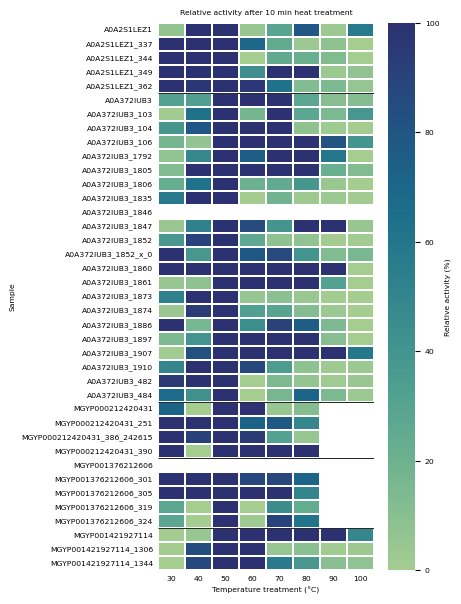

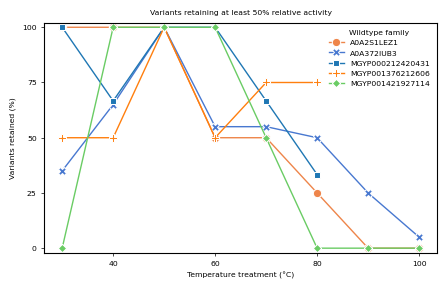

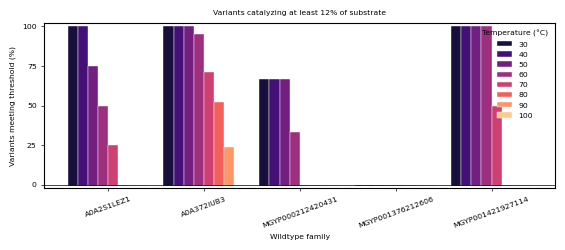

In [99]:
Activity_resistance_B3_dir = "/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Activity_Resistance/Batch_3/ThermoGAN_Batch3_Assay_20231025"

# Several sequences are more active after mild heating than at 30 C,
# so "max" is the safer default reference for percent activity.
activity_fit_until_s = 540
activity_reference_mode = "temperature" #"max"
activity_reference_temperature = 50

activity_replicates_B3, activity_summary_B3, activity_percent_active_B3 = compile_activity_resistance(
    Activity_resistance_B3_dir,
    fit_until_s=activity_fit_until_s,
    reference_mode=activity_reference_mode,
    reference_temperature=activity_reference_temperature
)

display(activity_percent_active_B3.round(1))

activity_heatmap_size_mm = (110, 150)
activity_font_size = 5.5
retained_activity_threshold = 50
substrate_conversion_threshold = 12
threshold_evaluation_min_temperature = (
    activity_reference_temperature if activity_reference_mode == "temperature" else None
)

wildtype_threshold_loss_B3 = summarize_wildtype_threshold_loss(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

wildtype_conversion_loss_B3 = summarize_wildtype_conversion_loss(
    activity_summary_B3,
    substrate_conversion_threshold=substrate_conversion_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

print("Wildtype temperature at which relative activity first drops below the retained activity threshold")
display(wildtype_threshold_loss_B3.round(1))

activity_percent_substrate_catalyzed_B3 = (
    activity_summary_B3.pivot(index="sample_name", columns="temperature_c", values="percent_substrate_catalyzed")
    .reindex(index=activity_percent_active_B3.index, columns=activity_percent_active_B3.columns)
)

print(f"Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = {substrate_conversion_threshold}%)")
display(activity_percent_substrate_catalyzed_B3.round(1))

print("Wildtype temperature at which substrate conversion first drops below the activity requirement")
display(wildtype_conversion_loss_B3.round(1))


plot_activity_resistance_heatmap(
    activity_percent_active_B3,
    size_mm=activity_heatmap_size_mm,
    font_size=activity_font_size
)

variant_retention_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    include_wildtypes=False
)

variant_conversion_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    include_wildtypes=False,
    activity_metric_column="percent_substrate_catalyzed",
    retained_flag_column="retained_by_substrate_conversion",
    threshold_column_name="substrate_conversion_threshold"
)

display(variant_retention_summary_B3.round(1))

plot_variant_retention_by_wildtype(
    variant_retention_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    size_mm=(110, 70),
    font_size=activity_font_size
)

plot_variant_retention_bar_by_wildtype(
    variant_conversion_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    size_mm=(140, 60),
    font_size=activity_font_size,
    retained_quantity_label="of substrate"
)
plt.savefig("fraction_active_round3_2026_03_27.pdf", bbox_inches = "tight")